# Heavy ion jet quenching with ***ATLAS*** Open Data
### Data
Based on arXiv:1011.6182v2

In [849]:
# File reading
import uproot
# Analysis
import awkward as ak
import numpy as np
# Plotting
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica","Arial","Nimbus Sans","DejaVu Sans"],
    "svg.fonttype": "path"
})

# Constants
GeV = 1e-3
TeV = 1e-6

In [850]:
# - Useful plotting functions - #
# Use innerward facing ticks in all direction
def inner_ticks(ax:matplotlib.axes.Axes):
    ax.tick_params(direction="in",which="both",top=True,right=True)

# Plot an ATLAS Open Data label on a pair of axes
def atlas_label(ax:matplotlib.axes.Axes,loc="upper right",text="Open Data",fontsize=16,pos_ovr=None,msg=r"PbPb $\sqrt{s}=5.02\ \mathrm{TeV}$"):
    locs = {
        "upper left" : (.04, .88),
        "upper right": (.96, .88),
    }
    if (pos_ovr is not None) and isinstance(pos_ovr,tuple):
        pos = pos_ovr 
    else: pos = locs[loc]
    align = ("left","right","center"); ha = "left"
    for a in align:
        if a in loc: ha = a
    ax.text(
        *pos,r"$\mathbfit{ATLAS}$ "+text,
        transform=ax.transAxes,fontsize=fontsize,ha=ha,va="bottom"
    )
    if msg:
        ax.text(
            pos[0], pos[1]-.05, msg,
            transform=ax.transAxes, fontsize=fontsize*.75, ha=ha, va="bottom"
        )

In [ ]:
# Cutting functions
def cut_n_jets(jets:ak.Array,N=2)->ak.Array:
    return jets[ak.num(jets) >= N]

def cut_pt(jets:ak.Array,leading=100,subleading=25)->ak.Array:
    jets = jets[ak.argsort(jets["pt"],axis=1,ascending=False)]
    leading_mask = jets["pt"][:,0]*GeV > leading #GeV
    subleading_mask = jets["pt"][:,1]*GeV > subleading
    return jets[leading_mask & subleading_mask]

def cut_et(jets:ak.Array,leading=100,subleading=25)->ak.Array:
    jets["et"] = np.sqrt(jets["pt"]*jets["pt"] + jets["m"]*jets["m"])
    jets = jets[ak.argsort(jets["et"],axis=1,ascending=False)]
    leading_mask = jets["et"][:,0]*GeV > leading
    subleading_mask = jets["et"][:,1]*GeV > subleading
    return jets[leading_mask & subleading_mask]

def cut_eta(jets:ak.Array,eta=2.8):
    return jets[np.abs(jets["eta"][:,0]) < eta]

def cut_opp_hemispheres(jets:ak.Array)->ak.Array:
    return jets[np.abs(jets["phi"][:,1] - jets["phi"][:,0]) > np.pi*.5]

# Get the number of entries in a jagged awkward array
def get_entries(array:ak.Array):
    return ak.sum(ak.num(array))

# Function to update cutflow dictionary after applying a cut to jets
def update_cutflow(cut:str,jets:ak.Array,cutflow=cutflow):
    cutflow["event"][cut], cutflow["track"][cut] = len(jets), get_entries(jets)

In [852]:
# Group event numbers by centrality
def group_by_centrality(fcal:ak.Array)->dict:
    centrality_ranges = {
        "(40 - 100)%": {
            "upper": 0.9, # TeV
            "lower": 0. # TeV
        },
        "(20 - 40)%": {
            "upper": 2.1,
            "lower": 0.9
        },
        "(10 - 20)%": {
            "upper": 3,
            "lower": 2.1
        },
        "(0 - 10)%": {
            "upper":9e9,
            "lower": 3
        }
    }

    fcal["TotalEt"] = fcal["FCalEtA"] + fcal["FCalEtC"]
    for range in centrality_ranges:
        upper, lower = centrality_ranges[range]["upper"], centrality_ranges[range]["lower"]
        upper_mask, lower_mask = fcal["TotalEt"]*TeV < upper, fcal["TotalEt"]*TeV >= lower
        centrality_ranges[range]["event_numbers"] = fcal[upper_mask & lower_mask]["eventNumber"]
    
    return centrality_ranges

In [853]:
def get_jets_fcal(path:str):
    with uproot.open(path) as tree:
        # Fill array with jet kinematics
        # Branches are renamed from full branch names to e.g. "pt"
        jets = ak.zip({
            branch.split("_")[1]: tree[branch].array() for branch in (
                "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_pt",
                "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_eta",
                "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_phi",
                "AntiKt4HIJetsAuxDyn.JetConstitScaleMomentum_m"
            )
        } | {
            "eventNumber": tree["EventInfoAuxDyn.eventNumber"].array()
        })

        # Fill FCal transverse energies and similarly reformat branch names
        fcal = ak.zip({
            branch.split(".")[1]: tree[branch].array() for branch in (
                f"EventInfoAuxDyn.FCalEt{x}" for x in ("A","C")
            )
        } | {
            "eventNumber": tree["EventInfoAuxDyn.eventNumber"].array()
        })
    return jets, fcal

In [854]:
def apply_plot_cuts(jets:ak.Array,fcal:ak.Array,mc=False):
    this_cutflow = {
        "event": {},
        "track": {}
    }
    update_cutflow("initial",jets,this_cutflow)

    jets = cut_n_jets(jets); update_cutflow("n_jets",jets,this_cutflow)
    jets = cut_et(jets); update_cutflow("et",jets,this_cutflow)
    jets = cut_eta(jets); update_cutflow("eta",jets,this_cutflow)
    jets = cut_opp_hemispheres(jets); update_cutflow("hemispheres",jets,this_cutflow)

    xlabels = [scope for scope in this_cutflow["event"]]
    cuts = [this_cutflow["event"][scope] for scope in xlabels]
    fig, ax = plt.subplots()
    ax.bar(xlabels,cuts,width=1.,linewidth=.5,edgecolor="k",color="blue")
    ax.set_xticks(xlabels); ax.set_xticklabels(xlabels,rotation=35,ha="right")
    inner_ticks(ax)
    ax.margins(x=0)
    ax.set_ylabel("Number of events"); ax.set_xlabel("Cut")
    atlas_label(ax,msg=r"PbPb $\sqrt{s}=5.02\ \mathrm{TeV}$" if not mc else r"PbPb MC $\sqrt{s}=5.02\ \mathrm{TeV}$")

    return jets, fcal, fig

In [855]:
def bin_jets_by_centrality(jets:ak.Array,fcal:ak.Array):
    centralities = group_by_centrality(fcal)
    # Grab jet event numbers.
    # Only the first number need be taken as this will
    # be repeated for every jet in an event.
    jet_enums = jets["eventNumber"][:,0]

    jet_centralities = {c: jets[np.isin(jet_enums,centralities[c]["event_numbers"])] for c in centralities}

    return jet_centralities

# Calculate dijet asymmetry factor A_J
def calculate_aj(jets:ak.Array):
    AJ = (jets["et"][:,0]-jets["et"][:,1])/(jets["et"][:,0]+jets["et"][:,1])
    return AJ
def plot_aj(jet_centralities:dict,mc=False):
    fig, ax = plt.subplots()
    AJ = {c: calculate_aj(jet_centralities[c]) for c in jet_centralities}
    max_aj = np.ceil((np.max(np.concatenate([AJ[c] for c in AJ])))*1e2)*1e-2
    print(max_aj)
    
    cols = ["black","blue","green","red"]
    for i,c in enumerate(AJ):
        h, bin_edges = np.histogram(AJ[c],bins=20,range=(0,max_aj),density=True)
        ax.stairs(h,bin_edges,label=c,color=cols[i])

    ax.set_xlabel(r"Dijet $A_J$"); ax.set_ylabel("Probability density")
    atlas_label(ax,msg=r"PbPb $\sqrt{s}=5.02\ \mathrm{TeV}$" if not mc else r"PbPb MC $\sqrt{s}=5.02\ \mathrm{TeV}$")
    inner_ticks(ax)

    ax.legend(frameon=False,loc="upper left")
    ax.margins(y=.4)

    return AJ, fig



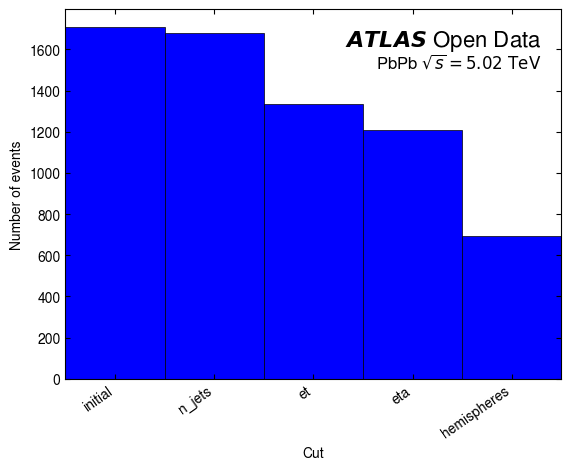

In [856]:
# Get data
jets, fcal = get_jets_fcal("DAOD_HIONHPOD_DATA.output.pool.root:CollectionTree")
jets, fcal, fig = apply_plot_cuts(jets,fcal)

0.21


/home/atlas/rjackson/.local/lib/python3.9/site-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


({'(40 - 100)%': <Array [] type='0 * float32'>,
  '(20 - 40)%': <Array [0.0799, 0.111, 0.0724, ..., 0.0861, 0.0261] type='108 * float32'>,
  '(10 - 20)%': <Array [0.00709, 0.00781, 0.046, ..., 0.0132, 0.0517] type='257 * float32'>,
  '(0 - 10)%': <Array [0.0137, 0.0285, 0.0716, ..., 0.0195, 0.0185] type='327 * float32'>},
 <Figure size 640x480 with 1 Axes>)

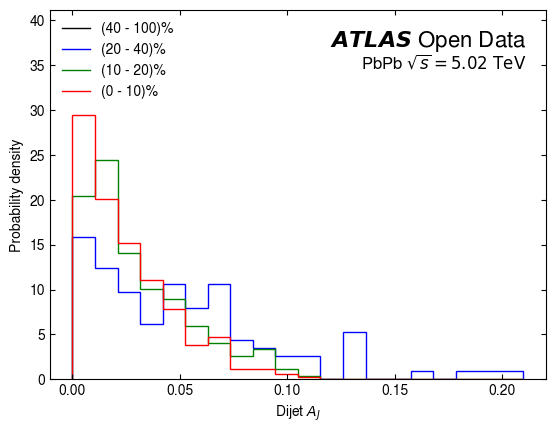

In [857]:
jet_centralities = bin_jets_by_centrality(jets,fcal)
plot_aj(jet_centralities)

In [858]:
# Plot a cutflow bar chart
# xlabels = [scope for scope in cutflow["event"]]
# cuts = [cutflow["event"][scope] for scope in xlabels]
# cutflow_fig, cutflow_ax = plt.subplots()
# cutflow_ax.bar(xlabels,cuts,width=1.,linewidth=.5,edgecolor="k",color="blue")
# cutflow_ax.set_xticks(xlabels); cutflow_ax.set_xticklabels(xlabels, rotation=35, ha="right")
# inner_ticks(cutflow_ax)
# cutflow_ax.margins(x=0)
# cutflow_ax.set_ylabel("Number of events"); _ = cutflow_ax.set_xlabel("Cut")
# atlas_label(cutflow_ax,msg=r"PbPb $\sqrt{s}=5.02\ \mathrm{TeV}$")

In [859]:
centralities = group_by_centrality(fcal)
jet_eventNumbers = jets["eventNumber"][:,0]
central_jets = jets[np.isin(jet_eventNumbers,centralities["(0 - 10)%"]["event_numbers"])]
peripheral_jets = jets[np.isin(jet_eventNumbers,centralities["(10 - 20)%"]["event_numbers"])]
print(central_jets["pt"])

[[1.61e+05, 1.57e+05, 1.53e+05, ..., 7.38e+04, 6.93e+04, 6.13e+04], ..., [...]]


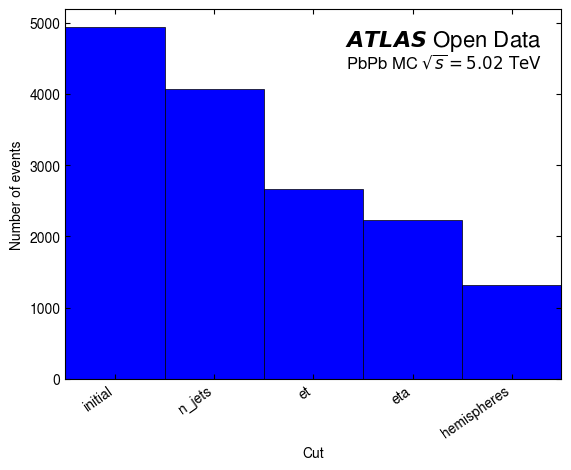

In [860]:
mc_jets, mc_fcal = get_jets_fcal("DAOD_HIONHPOD_jetmc.output.pool.root:CollectionTree")
mc_jets, mc_fcal, fig = apply_plot_cuts(mc_jets,mc_fcal,mc=True)

0.24


({'(40 - 100)%': <Array [0.235] type='1 * float32'>,
  '(20 - 40)%': <Array [0.062, 0.0306, 0.0242, ..., 0.111, 0.02, 0.0182] type='108 * float32'>,
  '(10 - 20)%': <Array [0.0146, 0.0352, 0.0357, ..., 0.0622, 0.0261] type='579 * float32'>,
  '(0 - 10)%': <Array [0.018, 0.0113, 0.0321, ..., 0.0132, 0.0368] type='635 * float32'>},
 <Figure size 640x480 with 1 Axes>)

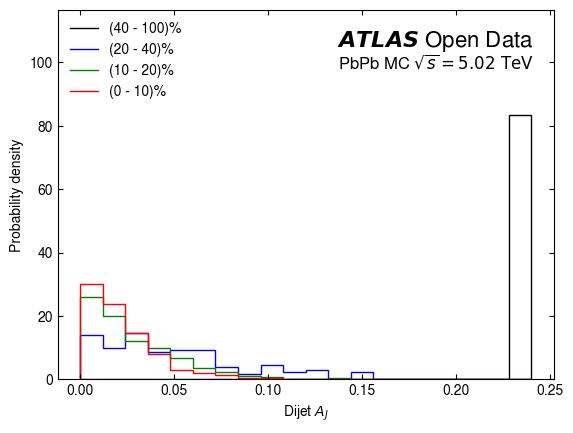

In [861]:
mc_jet_centralities = bin_jets_by_centrality(mc_jets,mc_fcal)
plot_aj(mc_jet_centralities,mc=True)